In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

data_dir = 'data'

In [21]:
data_path = os.path.join(data_dir, "processed_data.parquet")
df = pd.read_parquet(data_path)
df.head(5)


,banknifty,nifty,tte
time,,,
2021-01-01 09:15:00,0.286058,0.199729,27
2021-01-01 09:16:00,0.285381,0.200433,27
2021-01-01 09:17:00,0.284233,0.200004,27
2021-01-01 09:18:00,0.286104,0.199860,27
2021-01-01 09:19:00,0.285539,0.198951,27


#### **tte** Time To Expiry is the amount of time remaining until a financial contract expires.

In [22]:
print(df.info())
print("-"*50)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 687013 entries, 2021-01-01 09:15:00 to 2022-06-30 15:30:00
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   banknifty  687013 non-null  float64
 1   nifty      687013 non-null  float64
 2   tte        687013 non-null  int32  
dtypes: float64(2), int32(1)
memory usage: 18.3 MB
None
--------------------------------------------------
           banknifty          nifty            tte
count  687013.000000  687013.000000  687013.000000
mean        0.250154       0.179344      15.672436
std         0.057699       0.046139       8.664269
min         0.152732       0.089355       2.000000
25%         0.205307       0.140375       8.000000
50%         0.243977       0.181210      15.000000
75%         0.295293       0.215631      23.000000
max         0.460619       0.306952      31.000000


### plot of **BankNifty vs Nifty**

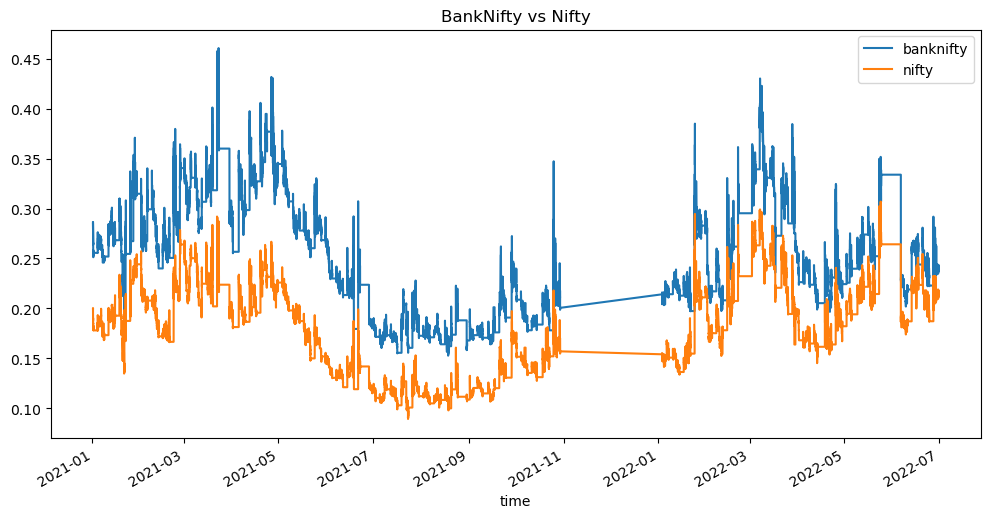

In [23]:
df[['banknifty', 'nifty']].plot(figsize=(12,6), title="BankNifty vs Nifty")
plt.show()


## Spread
**difference between two related financial time series.** $ Spread_t = A_t - B_t $

* spread measures the **relative distance between two assets**.
* Even if two indices move in the same general direction, their **difference fluctuates over time**. This difference can reveal:
   * temporary divergence between the two series
   * convergence behavior
   * abnormal deviations from typical relationships


### Why Spread is Useful

The spread helps identify **relative mispricing** between two correlated assets.
If two assets historically move together, then large deviations in spread may indicate:

* one asset temporarily overvalued
* the other undervalued
* a potential opportunity for mean reversion



## Z-Score of the Spread

standardizes the spread by measuring how far it deviates from its historical average in units of standard deviation.

$$ Z_t = \frac{Spread_t - \mu_{Spread}}{\sigma_{Spread}} $$


* z-score answers the question: **“How unusual is the current spread compared to its normal behavior?”**

Instead of looking at the raw difference, we measure **how many standard deviations away from the average the spread currently is**.

### Why Standardization is Important

Raw spread values are difficult to interpret because their magnitude depends on the scale of the indices. The z-score removes this scale issue by converting values into **standard deviation units**, making them easier to interpret and compare over time.
center**.

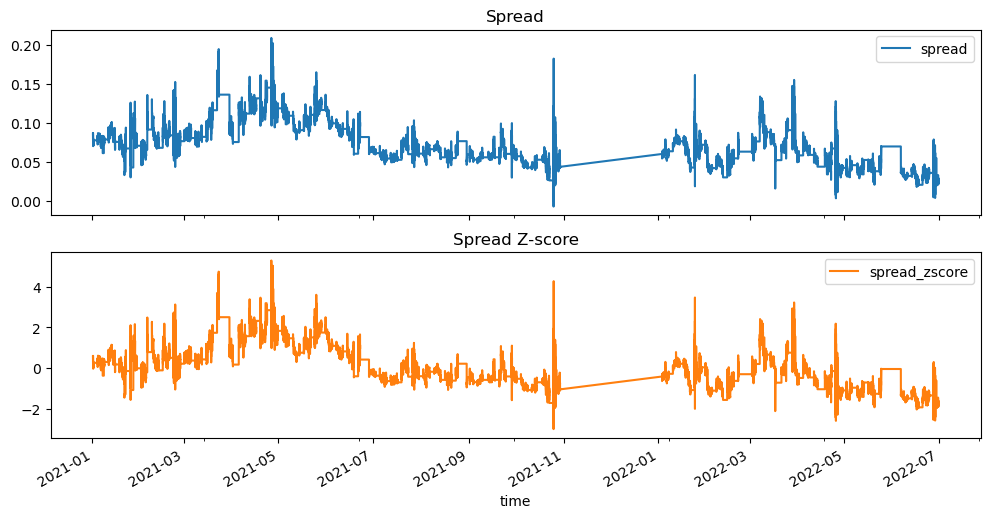

                     banknifty     nifty  tte    spread  spread_zscore
time                                                                  
2021-01-01 09:15:00   0.286058  0.199729   27  0.086329       0.592560
2021-01-01 09:16:00   0.285381  0.200433   27  0.084948       0.539849
2021-01-01 09:17:00   0.284233  0.200004   27  0.084229       0.512377
2021-01-01 09:18:00   0.286104  0.199860   27  0.086244       0.589295
2021-01-01 09:19:00   0.285539  0.198951   27  0.086588       0.602449


In [24]:
df['spread'] = df['banknifty'] - df['nifty']
df['spread_zscore'] = (df['spread'] - df['spread'].mean()) / df['spread'].std()
df[['spread','spread_zscore']].plot(figsize=(12,6), subplots=True, title=["Spread","Spread Z-score"])
plt.show()
print(df.head(5))


1. **Most of the time**
   * Z-score stays between **−1 and +1**
   * Spread behaving normally.

2. **Large positive spikes (≈ +4)**
   * BANKNIFTY extremely strong relative to NIFTY.

3. **Large negative spikes (≈ −3)**
   * BANKNIFTY suddenly weak relative to NIFTY.

These are **rare deviations from the normal relationship**.

### Trading / Statistical Interpretation
> core idea behind **pairs trading**.

### When Z-score is very high (e.g. > 2)
Spread is unusually large. Interpretation can be BANKNIFTY overpriced relative to NIFTY.

Typical trade:
* **Short BANKNIFTY**
* **Long NIFTY**

Expect spread to **decrease**.



### When Z-score is very low (e.g. < −2)

Spread unusually small. Interpretation can be BANKNIFTY underpriced relative to NIFTY.

Typical trade:

* **Long BANKNIFTY**
* **Short NIFTY**

Expect spread to **increase**


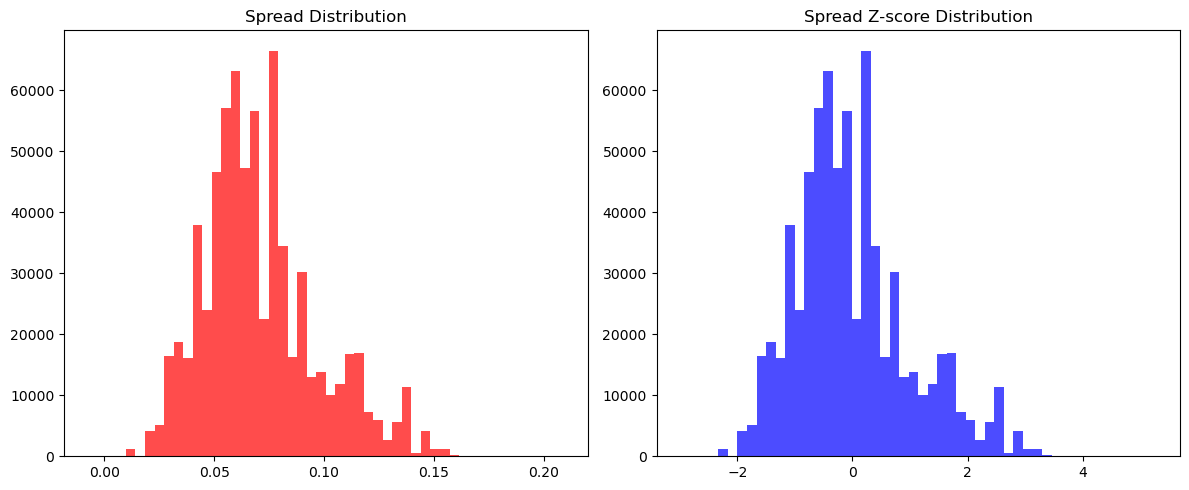

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['spread'], bins=50, color='red', alpha=0.7)
axes[0].set_title("Spread Distribution")
axes[1].hist(df['spread_zscore'], bins=50, color='blue', alpha=0.7)
axes[1].set_title("Spread Z-score Distribution")
plt.tight_layout()
plt.show()


In [26]:
df[['banknifty','nifty','spread','spread_zscore','tte']].corr()

,banknifty,nifty,spread,spread_zscore,tte
banknifty,1.000000,0.896274,0.624149,0.624149,-0.069655
nifty,0.896274,1.000000,0.212899,0.212899,-0.055691
spread,0.624149,0.212899,1.000000,1.000000,-0.055346
spread_zscore,0.624149,0.212899,1.000000,1.000000,-0.055346
tte,-0.069655,-0.055691,-0.055346,-0.055346,1.000000


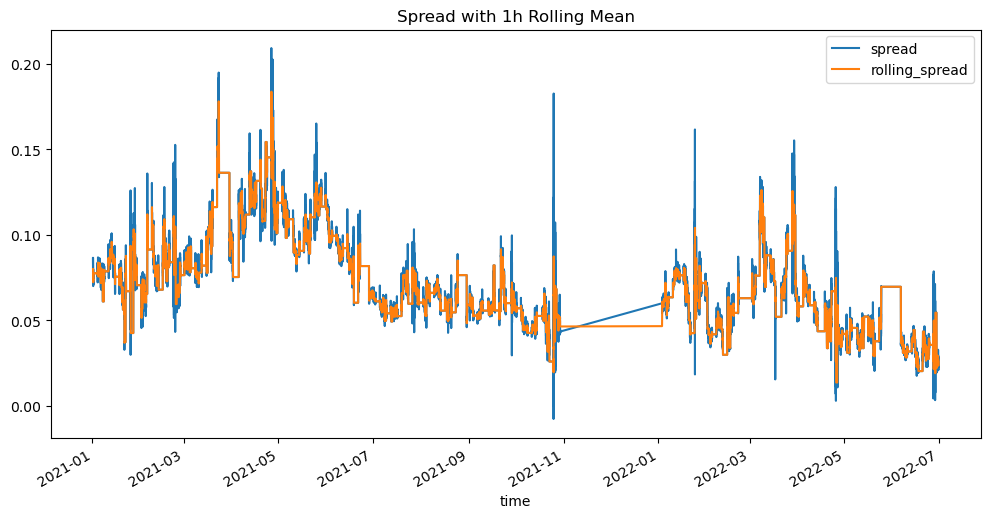

In [27]:
window = 60  # 1 hour
df['rolling_spread'] = df['spread'].rolling(window).mean()

df[['spread', 'rolling_spread']].plot(figsize=(12,6), title="Spread with 1h Rolling Mean")
plt.show()

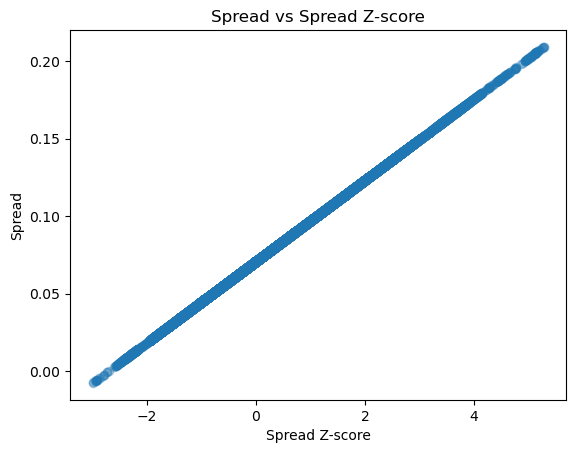

In [28]:
plt.scatter(df['spread_zscore'], df['spread'], alpha=0.3)
plt.xlabel("Spread Z-score")
plt.ylabel("Spread")
plt.title("Spread vs Spread Z-score")
plt.show()

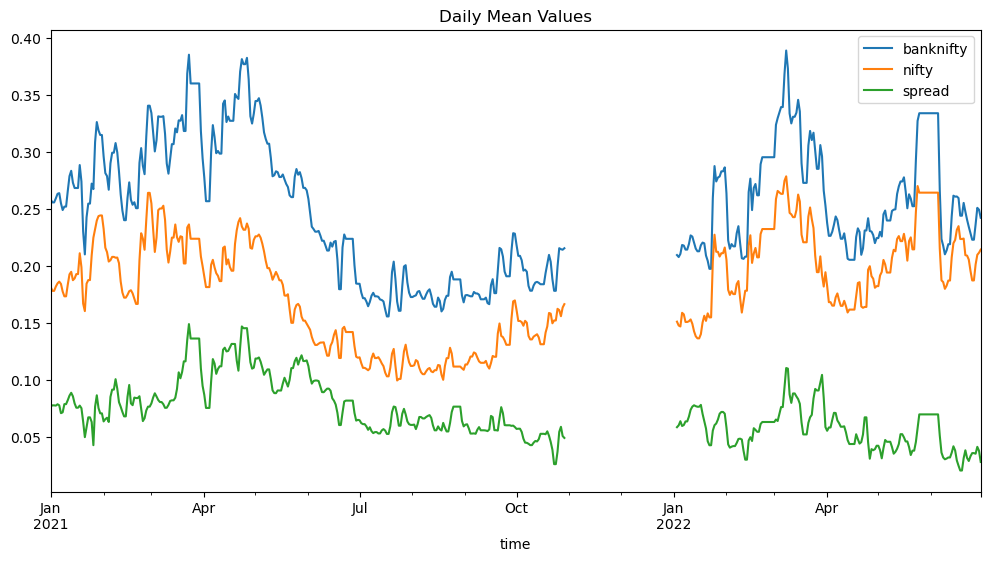

In [29]:
# Daily mean values
daily = df.resample("1D").mean()

daily[['banknifty','nifty','spread']].plot(figsize=(12,6), title="Daily Mean Values")
plt.show()


## Non-Overlapping Block mean

Instead of computing a rolling mean, we divide the data into **separate hourly blocks** - first 60 in first block, next 60 in next block. Each block represents **one hour of trading activity**.


### Why We Use Non-Overlapping Means

This is very useful for:

- 1. Noise Reduction : Minute spreads fluctuate randomly. Hourly averages reveal the **true structural behaviour**.
- 2. Regime Detection : helps to detect periods where the spread shifts.

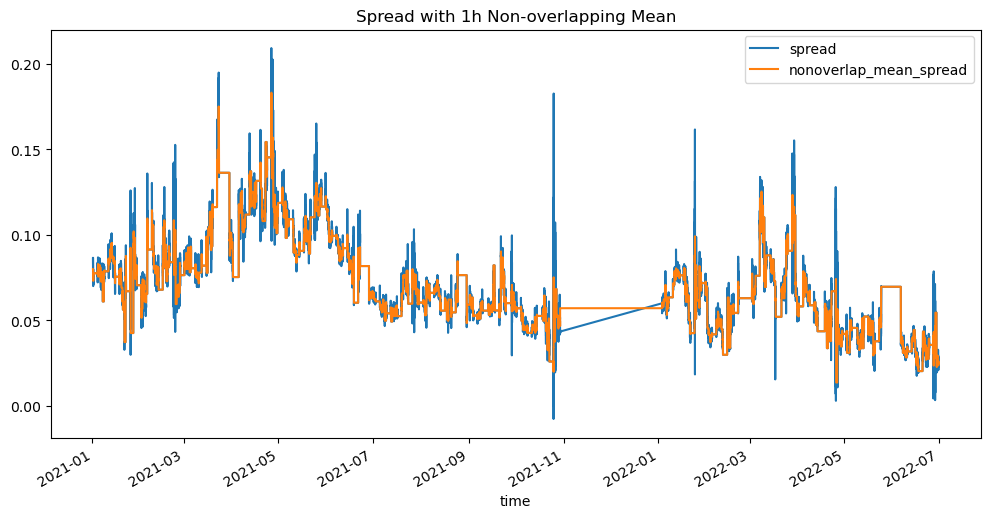

In [30]:
window = 60  # 1 hour = 60 minutes
block = np.arange(len(df)) // window  

df['nonoverlap_mean_spread'] = df.groupby(block)['spread'].transform('mean')

df[['spread','nonoverlap_mean_spread']].plot(figsize=(12,6), title="Spread with 1h Non-overlapping Mean")
plt.show()


### Non-Overlapping Block mean - by time 
eg, 9:15 to 10:14 in 1 block, 10:15 to 11:14 in next block and so on ....

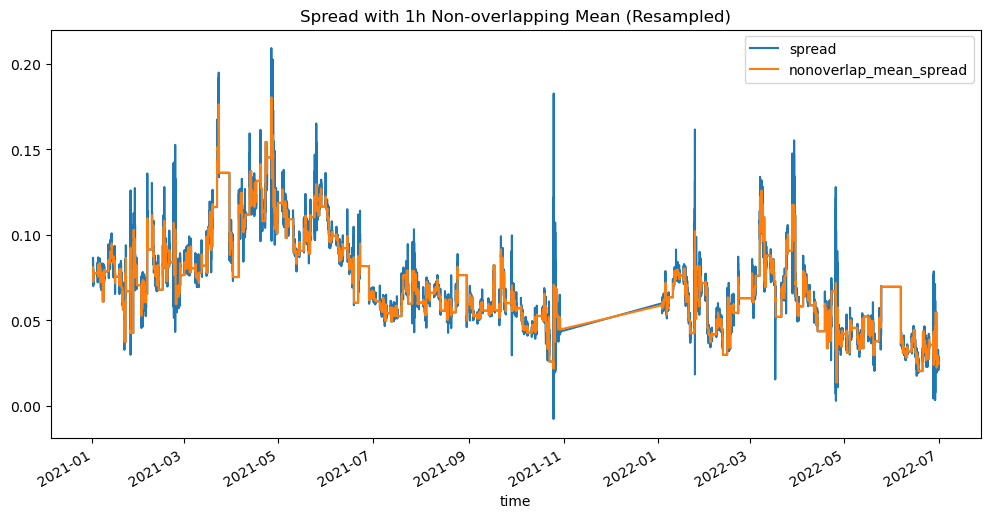

In [31]:
# Compute 1-hour averages
hourly = df['spread'].resample("1h").mean()

# Merge back into original dataframe
df['nonoverlap_mean_spread'] = hourly.reindex(df.index, method='ffill')

df[['spread','nonoverlap_mean_spread']].plot(figsize=(12,6), title="Spread with 1h Non-overlapping Mean (Resampled)")
plt.show()

### Spread vs local score(block z-score)

1. Splits the spread data into **1-hour windows**
2. Computes **hour-specific mean and volatility**
3. Standardizes the spread using **local z-scores**
4. Plots how the raw spread relates to its **relative deviation** 
   - x-axis: local z-score of the spread
   - y-axis: raw spread value

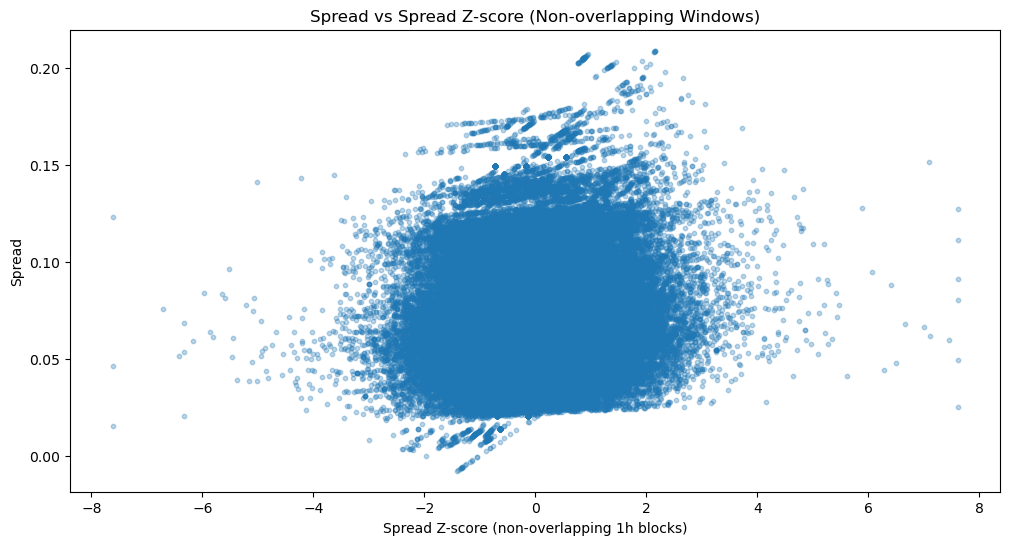

In [32]:
window = 60  # 1 hour (60 minutes)

# assign block index: 0 for first 60 rows, 1 for next 60, etc.
block = np.arange(len(df)) // window

# compute block-level mean & std of spread
block_mean = df.groupby(block)['spread'].transform('mean')
block_std  = df.groupby(block)['spread'].transform('std')

# z-score within each block
df['spread_nonoverlap_mean'] = block_mean
df['spread_nonoverlap_z'] = (df['spread'] - block_mean) / block_std

# Plot
plt.figure(figsize=(12,6))
plt.scatter(df['spread_nonoverlap_z'], df['spread'], alpha=0.3, s=10)
plt.xlabel("Spread Z-score (non-overlapping 1h blocks)")
plt.ylabel("Spread")
plt.title("Spread vs Spread Z-score (Non-overlapping Windows)")
plt.show()

### inference from above plot
* spread deviations behave roughly linearly with z-score
* spread levels shift across hours
* extreme deviations exist (possible trading signals)
* volatility changes over time


### Density of **Spread vs local Z-score**
It tells us where **most spread observations lie** vs **how extreme the spread is relative to its hourly behavior**

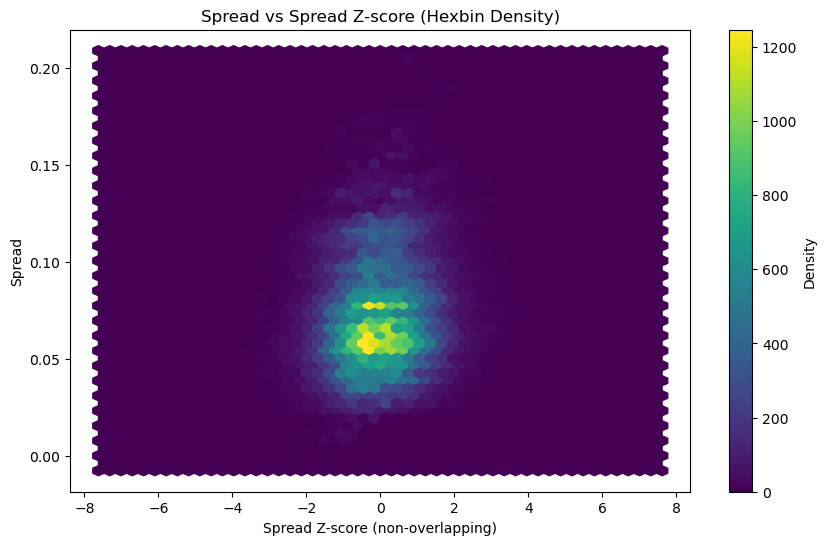

In [33]:
plt.figure(figsize=(10,6))
plt.hexbin(df['spread_nonoverlap_z'], df['spread'], gridsize=50, cmap='viridis')
plt.colorbar(label="Density")
plt.xlabel("Spread Z-score (non-overlapping)")
plt.ylabel("Spread")
plt.title("Spread vs Spread Z-score (Hexbin Density)")
plt.show()


### KDE  - Kernel Density Estimate
A **Kernel Density Estimate** works by placing a small smooth function (kernel, usually Gaussian) around each observation.

Conceptually:
```
each data point → small smooth bump
sum of bumps → smooth probability surface
```

The final result approximates the **underlying distribution of the data**.So, instead of discrete points, we gget see **smooth density contours**.

KDE plot shows the **joint density of spread and its local z-score** highlighting:
* the most common spread levels
* how spread behaves relative to its hourly mean
* where extreme deviations occur

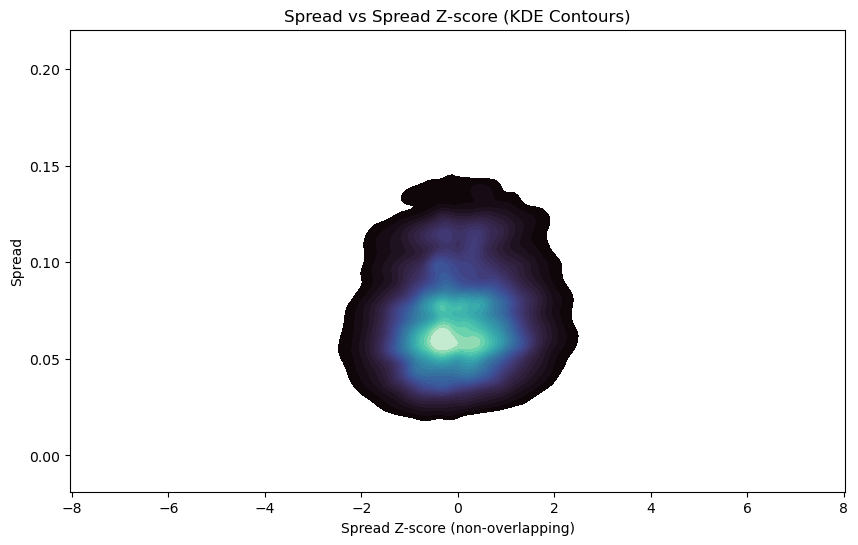

In [34]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    x=df['spread_nonoverlap_z'],
    y=df['spread'],
    fill=True, levels=30, cmap="mako"
)
plt.xlabel("Spread Z-score (non-overlapping)")
plt.ylabel("Spread")
plt.title("Spread vs Spread Z-score (KDE Contours)")
plt.show()

| Plot    | What it Shows                   |
| ------- | ------------------------------- |
| Scatter | raw data points                 |
| Hexbin  | density by bin counts           |
| KDE     | smooth probability distribution |

In [35]:
df.head(5)

,banknifty,nifty,tte,spread,spread_zscore,rolling_spread,nonoverlap_mean_spread,spread_nonoverlap_mean,spread_nonoverlap_z
time,,,,,,,,,
2021-01-01 09:15:00,0.286058,0.199729,27,0.086329,0.592560,NaN,0.081015,0.080008,1.846373
2021-01-01 09:16:00,0.285381,0.200433,27,0.084948,0.539849,NaN,0.081015,0.080008,1.443137
2021-01-01 09:17:00,0.284233,0.200004,27,0.084229,0.512377,NaN,0.081015,0.080008,1.232975
2021-01-01 09:18:00,0.286104,0.199860,27,0.086244,0.589295,NaN,0.081015,0.080008,1.821399
2021-01-01 09:19:00,0.285539,0.198951,27,0.086588,0.602449,NaN,0.081015,0.080008,1.922026


# Conclusion from the Analysis

### BankNifty and Nifty Move Together

The time series plot shows that **BankNifty and Nifty follow similar market movements**. This suggests a **strong relationship between the two indices**, which makes analyzing their spread meaningful.


### Spread is Relatively Stable

The spread defined as $ Spread = BankNifty - Nifty $
remains within a **bounded range most of the time**, indicating a **stable relationship between the two indices**.

This behavior is consistent with **mean-reverting spreads**, which is important for statistical arbitrage.


### Most Spread Deviations Are Small

From the **spread distribution and z-score histogram**:

* Most observations lie between **−1 and +1 z-score**
* Large deviations are **rare**

This means the spread usually stays **close to its normal level**.



### Extreme Deviations Occasionally Occur

There are occasional **large positive or negative z-scores (≈ ±3 or more)**.

These represent **temporary dislocations between BankNifty and Nifty**, which could potentially be **trading opportunities**.


### Spread Behavior Changes Across Time

Using **hourly rolling mean and non-overlapping hourly means**, we see that:

* the **average spread shifts over time**
* volatility of the spread **varies during different hours**

So the spread is **not constant**, but **locally stable within short periods**.



### Local Z-Score Normalization

When the spread is normalized within each **1-hour block**:

* deviations become easier to compare across time
* intraday volatility differences are removed

This produces a **stationary signal useful for trading models**.


### Density and KDE Plots

The hexbin and KDE plots show that:

* most observations concentrate around **Z ≈ 0**
* probability decreases as **|Z| increases**
* extreme spread values are **rare events**

This confirms the **spread is centered around a local equilibrium**.

## Overall Interpretation

The analysis suggests:

* **BankNifty and Nifty are strongly related**
* their spread is **bounded and often mean-reverting**
* **extreme deviations occur occasionally**
* spread dynamics vary **across time (intraday regimes)**

This makes the spread a **potential candidate for statistical arbitrage or pairs trading strategies**.